# Threshold Example Notebook
## Import packages and install climakitae

In [1]:
import xarray as xr
import panel as pn

pn.extension()

In [6]:
#### for development - force uninstall previously installed version of climatkitae to require a new one be grabbed from git
!pip uninstall -y climakitae

Found existing installation: climakitae 0.0.1
Uninstalling climakitae-0.0.1:
  Successfully uninstalled climakitae-0.0.1


In [7]:
#!pip install https://github.com/cal-adapt/climakitae/archive/main.zip
#!pip install git+https://github.com/cal-adapt/climakitae.git@threshold
!pip install --no-cache-dir git+https://github.com/cal-adapt/climakitae.git@threshold

#Install needed package to calculate parameters for extreme distributions via L-Moments
#climakitae includes lmoments 1.0.1, which references scipy functionality which has been depreciated
#command below installs lmoments 1.0.4 which does not make references to missing/depreciated values
!pip install git+https://github.com/OpenHydrology/lmoments3.git




  Cloning https://github.com/cal-adapt/climakitae.git (to revision threshold) to /tmp/pip-req-build-rpn4yo0_
  Running command git clone -q https://github.com/cal-adapt/climakitae.git /tmp/pip-req-build-rpn4yo0_
  Running command git checkout -b threshold --track origin/threshold
  Switched to a new branch 'threshold'
  Branch 'threshold' set up to track remote branch 'threshold' from 'origin'.
  Created wheel for climakitae: filename=climakitae-0.0.1-py3-none-any.whl size=13664 sha256=6bd57bba0d83364737d99cae14788dffddeb0b33e06c1a04c26422be4bc6e106
  Stored in directory: /tmp/pip-ephem-wheel-cache-g8h22o4u/wheels/f9/2c/31/7994216803c6359b8b61ad05327dbe63083af6419823be581b
Successfully built climakitae
  Cloning https://github.com/OpenHydrology/lmoments3.git to /tmp/pip-req-build-_ux97hp6
  Running command git clone -q https://github.com/OpenHydrology/lmoments3.git /tmp/pip-req-build-_ux97hp6


In [8]:
import climakitae as ck
from climakitae import threshold_tools


In [9]:
#for debuging delete before soft launch
threshold_tools.get_aicc_stat??

Signature: threshold_tools.get_aicc_stat(ams, multiple_points=True)
Docstring: <no docstring>
Source:   
def get_aicc_stat(ams, multiple_points=True):

    ams_attributes = ams.attrs

    if multiple_points == True:
        ams = ams.stack(allpoints=["x", "y"]).squeeze().groupby("allpoints")

    def apply_function(ams):
        def function(ams):

            try:
                lmoments_gev = ldistr.gev.lmom_fit(ams)
                aicc_gev = ["gev", lstats.AICc(ams, "gev", lmoments_gev)]
            except ValueError:
                aicc_gev = ["gev", np.nan]

            try:
                lmoments_gum = ldistr.gum.lmom_fit(ams)
                aicc_gum = ["gumbel", lstats.AICc(ams, "gum", lmoments_gum)]
            except ValueError:
                aicc_gum = ["gumbel", np.nan]

            try:
                lmoments_wei = ldistr.wei.lmom_fit(ams)
                aicc_wei = ["weibull", lstats.AICc(ams, "wei", lmoments_wei)]
            except ValueError:
                a

In [5]:
#for debuging delete before soft launch
#help(ck)
#dir(ck)


## Threshold Example on a Grid or Multiple Locations
# Step 1: Select
### Load a new application and call 'select' to display interface from which to choose location, variables, scenarios, and designate warming levels of interest

In [10]:
app = ck.Application()

## Now we can call 'select' to display an interface from which to select the data to examine.
### For this example, please select an area or region rather than a single gridpoint
### This version only offers the dynamically-downscaled data. e.g.If you select 'daily' for 'Timescale' it will result in a daily average of the hourly data.
#### Example bounds for California: 32.5, 42; -114, -125.5
#### Since there is no "enter" button, probably need to remind users to shift+enter to move on


Column
    [0] Row
        [0] Column
            [0] Select(name='Timescale', options=OrderedDict([('hourly', ...]), value='monthly')
            [1] Select(name='Variable', options=OrderedDict([('Instantaneo...]), value='T2')
            [2] RadioButtonGroup(name='Resolution', options=OrderedDict([('9 km', ...]), value='45 km')
        [1] CheckBoxGroup(name='Scenario', options=OrderedDict([('Historical ...]), value=['Historical Climate'])
    [1] Row
        [0] Column(margin=5, name='LocSelectorArea', width=300)
            [0] StaticText(value='<b>LocSelectorArea</b>')
            [1] Select(name='Area subset', options=OrderedDict([('none', ...]), value='lat/lon')
            [2] RangeSlider(end=67, name='Latitude', start=10, step=1, value=(35, 39), value_end=39, value_start=35)
            [3] RangeSlider(end=-84.18701, name='Longitude', start=-156.82317, value=(-123.72317000000001, ..., value_end=-119.72317000000001, value_start=-123.72317000000001)
            [4] Select(name='Cached area', options=OrderedDict([('CA', ...]), value='CA')
        [1] ParamMethod(method)
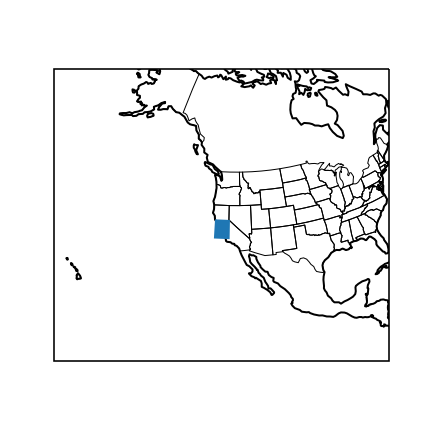

In [12]:
app.select()

# Step 2: Generate
## Finally, call app.generate() to load the subset/combo of data specified

In [ ]:
data_to_use = app.generate()

### (Optional) You can preview the data in the generated dataset when this is complete. It may take several minutes.

In [ ]:
data_to_use

# Section 3: Transform
### Now we begin doing calculations for extreme value analysis
### First, identify what conditions are extreme - here we default to considering each annual maximum value as a sample of an extreme event
### Future approaches will include the option to specify a threshold (i.e. critical value for infrastructure or high percentile) as the basis for identifying extremes

In [27]:


ams = threshold_tools.get_ams(data_to_use, extremes_type='max')
ams



<xarray.DataArray 'T2' (scenario: 1, simulation: 4, time: 35, y: 19, x: 17)>
dask.array<transpose, shape=(1, 4, 35, 19, 17), dtype=float32, chunksize=(1, 1, 1, 19, 17), chunktype=numpy.ndarray>
Coordinates:
  * time               (time) datetime64[ns] 1980-12-31 ... 2014-12-31
    Lambert_Conformal  int32 1
    lakemask           (y, x) float32 dask.array<chunksize=(19, 17), meta=np.ndarray>
    landmask           (y, x) float32 dask.array<chunksize=(19, 17), meta=np.ndarray>
    lat                (y, x) float32 dask.array<chunksize=(19, 17), meta=np.ndarray>
    lon                (y, x) float32 dask.array<chunksize=(19, 17), meta=np.ndarray>
  * x                  (x) float64 -4.485e+06 -4.44e+06 ... -3.81e+06 -3.765e+06
  * y                  (y) float64 1.034e+06 1.079e+06 ... 1.799e+06 1.844e+06
  * simulation         (simulation) <U13 'cesm2' ... 'mpi-esm1-2-lr'
  * scenario           (scenario) <U18 'Historical Climate'
Attributes:
    extreme value extraction method:  block maxima
    extremes type:                    maxima
    block size:                       1 year
    timeseries type:                  annual max series

In [11]:
### Next, we employ a test (Akaike information criterion) to identify the extreme value distribution/fit which is best for the data you previously selected

In [59]:
#debugging code, delete later
#threshold_tools.get_aicc_stat??

In [73]:
model_selection = threshold_tools.get_aicc_stat(ams, multiple_points=True)
model_selection

AttributeError: 'str' object has no attribute 'copy'

In [ ]:
### Utilize KS test to calculate goodness of fit of selected distribution

In [ ]:
goodness_of_fit = threshold_tools.get_ks_stat(ams, distr='gev', multiple_points=True)
goodness_of_fit

In [ ]:
### Calculate return value for a selected return period
#### Specify the return period of interest, in years, by changing the return_period= 

In [ ]:
return_value = threshold_tools.get_return_value(ams, return_period=10, distr='gev', multiple_points=True)
return_value

In [ ]:
### Calculate return probability for a selected threshold
#### Evaluate the probability of your choice by setting threshold = to the percentile of interest

In [ ]:
return_prob = threshold_tools.get_return_prob(ams, threshold=80, distr='pearson3', multiple_points=True)
return_prob

In [ ]:
### Calculate return period for a selected return value
#### Return value will have units equivalent to those of the variable you selected in Step #1: Select

In [ ]:
return_period = threshold_tools.get_return_period(ams, return_value=80, distr='weibull', 
                                  multiple_points=True)
return_period

In [ ]:
## Step 4: Visualize

In [ ]:
### Visualize model selection results
threshold_tools.get_frequency_plot(model_selection, data_variable='lowest_aicc_distr')

In [ ]:
### Visualize goodness of fit of distribution

threshold_tools.get_geospatial_plot(goodness_of_fit, data_variable='p_value')

In [ ]:
### Visualize return value

threshold_tools.get_geospatial_plot(return_value, data_variable='return_value')

In [ ]:
### Visualize return probability

threshold_tools.get_geospatial_plot(return_prob, data_variable='return_prob')

In [ ]:
### Visualize return period

threshold_tools.get_geospatial_plot(return_period, data_variable='return_period', bar_max=1000)

## Section 5: Finally, export the data:

In [ ]:
# [insert example]

In [ ]:
## Threshold Example on a Single Point
# Step 1: Select
### Load a new application and call 'select' to display interface from which to choose location, variables, scenarios, and designate warming levels of interest